In [2]:
# Step 0: Imports & Paths
import os, json, re, random, time
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np

# Text evaluation libs
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', quiet=True)

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
MAPPING_FILE = DATA_DIR / 'mapping.csv'   # confirmed by you
ENHANCED_DIR = DATA_DIR / 'enhanced_images'   # optional preview
OUTPUT_DIR = ROOT / 'Milestone_3_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('MAPPING_FILE:', MAPPING_FILE)
print('ENHANCED_DIR:', ENHANCED_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


ROOT: C:\Users\A\Desktop\Internship\EHR_Infosys
MAPPING_FILE: C:\Users\A\Desktop\Internship\EHR_Infosys\data\mapping.csv
ENHANCED_DIR: C:\Users\A\Desktop\Internship\EHR_Infosys\data\enhanced_images
OUTPUT_DIR: C:\Users\A\Desktop\Internship\EHR_Infosys\Milestone_3_outputs


In [4]:
# Step 1: Load mapping.csv
if not MAPPING_FILE.exists():
    raise FileNotFoundError(f"mapping.csv not found at {MAPPING_FILE}. Update path and rerun.")

mapping = pd.read_csv(MAPPING_FILE)
print('Loaded mapping.csv — rows:', len(mapping))
print('Columns:', mapping.columns.tolist())
display(mapping.head())


Loaded mapping.csv — rows: 20000
Columns: ['image_path', 'diagnosis', 'ehr_text']


,image_path,diagnosis,ehr_text
0,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,52
1,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,32
2,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,70
3,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,21
4,C:\Users\A\Desktop\Internship\EHR_Infosys\data...,normal,62


Previewing up to 6 enhanced images:


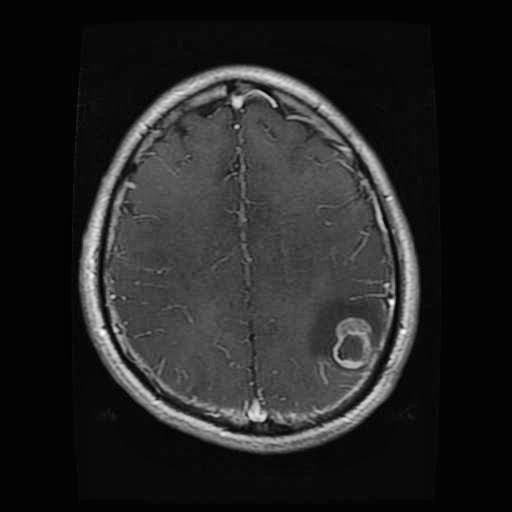

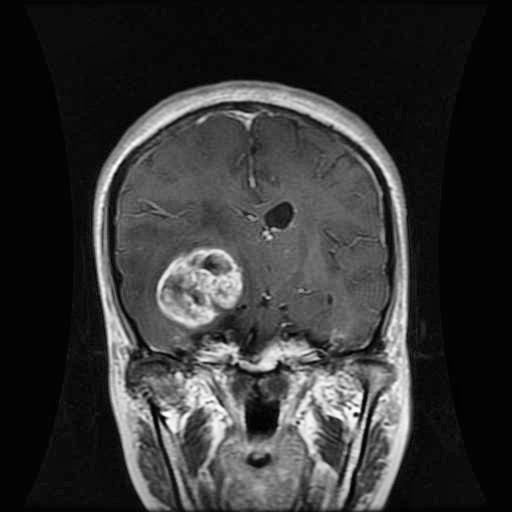

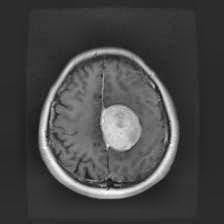

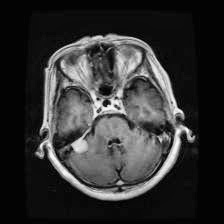

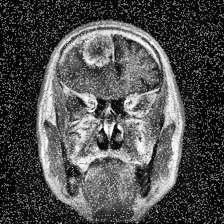

In [6]:
# Optional: preview some enhanced images if available
from IPython.display import Image, display
if ENHANCED_DIR.exists():
    files = list(ENHANCED_DIR.glob('*'))[:6]
    if files:
        print('Previewing up to 6 enhanced images:')
        for f in files:
            try:
                display(Image(str(f), width=220))
            except:
                pass
    else:
        print('No files in enhanced_images/')
else:
    print('enhanced_images/ not found — skipping image preview')


In [8]:
# Step 2: Prepare sample patient inputs (max 15)
df = mapping.copy()

# Ensure file_id exists
if 'file_id' not in df.columns:
    df['file_id'] = df.index.astype(str)

sample_n = min(15, len(df))
sample_df = df.sample(sample_n, random_state=42).reset_index(drop=True)

# Try to extract demographics from note_path; fallback to random
def extract_demo(path):
    try:
        p = Path(path)
        if p.exists():
            txt = p.read_text(encoding='utf-8', errors='ignore')
            age_m = re.search(r'Age[:\s]+(\d{1,3})', txt, re.I)
            gen_m = re.search(r'Gender[:\s]+(Male|Female)', txt, re.I)
            age = int(age_m.group(1)) if age_m else random.randint(20,75)
            gender = gen_m.group(1).title() if gen_m else random.choice(['Male','Female'])
            return age, gender
    except:
        pass
    return random.randint(20,75), random.choice(['Male','Female'])

ages, genders = zip(*sample_df.get('note_path', pd.Series(['']*len(sample_df))).apply(extract_demo))
sample_df['age'] = ages
sample_df['gender'] = genders

# Create patient names
random.seed(42)
male = ['Arjun','Rahul','Vikram','Rohan','Aditya','Neeraj','Karan','Aryan']
female = ['Ananya','Priya','Sneha','Divya','Aishwarya','Pooja','Riya','Shruti']
surnames = ['Sharma','Kumar','Singh','Patel','Gupta','Reddy','Joshi','Verma']
def name_for(g): return (random.choice(male) if g=='Male' else random.choice(female)) + ' ' + random.choice(surnames)
sample_df['patient_name'] = sample_df['gender'].apply(name_for)

# Synthesize MRI findings & symptoms based on diagnosis label
findings = {
    'Malignant': [
        'MRI shows an enhancing brain tumor with irregular margins and surrounding edema.',
        'Large hyperintense lesion on T1 with contrast enhancement suggestive of high-grade tumor.'
    ],
    'Benign': [
        'Smooth, homogeneous lesion with no aggressive features.',
        'Small non-enhancing lesion consistent with low-grade tumor.'
    ],
    'No Tumor': [
        'MRI brain is normal. No focal lesion or abnormality detected.',
        'No evidence of intracranial space-occupying lesion.'
    ]
}
symptoms = {
    'Malignant': ['Progressive headache, vomiting, seizures', 'Weakness in limbs'],
    'Benign': ['Mild headache', 'Occasional dizziness'],
    'No Tumor': ['No complaints', 'Routine check-up']
}

def classify_diag(d):
    if isinstance(d, str):
        dl = d.lower()
        if 'malignant' in dl or 'c71' in dl: return 'Malignant'
        if 'benign' in dl or 'd33' in dl or 'meningioma' in dl: return 'Benign'
    return 'No Tumor'

sample_df['category'] = sample_df['diagnosis'].apply(classify_diag)
sample_df['mri_findings'] = sample_df['category'].apply(lambda c: random.choice(findings[c]))
sample_df['symptoms'] = sample_df['category'].apply(lambda c: random.choice(symptoms[c]))

# Build final_input payload used for LLM
final_input = sample_df[['file_id','patient_name','age','gender','symptoms','mri_findings','diagnosis']].rename(
    columns={'file_id':'patient_id','diagnosis':'provisional_diagnosis'}
).to_dict('records')

# Save input payloads
INPUT_JSON = OUTPUT_DIR / 'INPUT_FOR_AI.json'
INPUT_CSV = OUTPUT_DIR / 'INPUT_FOR_AI.csv'
with open(INPUT_JSON, 'w', encoding='utf-8') as fh:
    json.dump(final_input, fh, indent=2, ensure_ascii=False)
pd.DataFrame(final_input).to_csv(INPUT_CSV, index=False)

print('Prepared', len(final_input), 'cases. Saved to', INPUT_JSON)
display(pd.DataFrame(final_input)[['patient_name','age','gender','provisional_diagnosis','symptoms']])


Prepared 15 cases. Saved to C:\Users\A\Desktop\Internship\EHR_Infosys\Milestone_3_outputs\INPUT_FOR_AI.json


,patient_name,age,gender,provisional_diagnosis,symptoms
0,Rahul Sharma,48,Male,normal,No complaints
1,Aishwarya Patel,53,Female,normal,Routine check-up
2,Rohan Singh,40,Male,normal,No complaints
3,Priya Kumar,48,Female,normal,No complaints
4,Riya Sharma,42,Female,normal,No complaints
5,Arjun Kumar,52,Male,normal,Routine check-up
6,Rohan Patel,59,Male,normal,Routine check-up
7,Arjun Patel,47,Male,normal,Routine check-up
8,Karan Patel,51,Male,normal,Routine check-up
9,Shruti Gupta,34,Female,normal,No complaints


In [10]:
# Step 3: Generate clinical notes + ICD-10 (MOCK or OPENAI)
USE_OPENAI = False  # set True to call OpenAI (remember to set OPENAI_API_KEY in env)

def mock_gen(p):
    clinical = (f"{p['patient_name']}, a {p['age']}-year-old {p['gender']}, presents with {p['symptoms']}. "
                f"{p['mri_findings']} Management: further evaluation and follow-up.")
    cat = 'Malignant' if 'Malignant' in p['provisional_diagnosis'] else ('Benign' if 'Benign' in p['provisional_diagnosis'] else 'No Tumor')
    icd = 'C71.9' if cat=='Malignant' else ('D33.9' if cat=='Benign' else 'G44.1')
    desc = 'Malignant neoplasm of brain, unspecified' if icd.startswith('C71') else ('Benign neoplasm of brain, unspecified' if icd.startswith('D33') else 'Tension-type headache')
    return {'clinical_note': clinical, 'icd10_code': icd, 'icd10_description': desc}

RESULTS = []

if USE_OPENAI:
    # Template OpenAI usage (uncomment and ensure OPENAI_API_KEY is set)
    import os, openai
    openai.api_key = os.getenv('OPENAI_API_KEY') or ''
    if not openai.api_key:
        raise ValueError('Set OPENAI_API_KEY in environment to use real API')

    def call_openai(p):
        prompt = f"""
You are a senior neurologist. Write a concise 4–6 sentence OPD clinical note and assign ONE ICD-10 code.
Patient: {p['patient_name']}, {p['age']}-year-old {p['gender']}
Symptoms: {p['symptoms']}
MRI: {p['mri_findings']}
Provisional Diagnosis: {p['provisional_diagnosis']}

Return ONLY valid JSON with keys clinical_note, icd10_code, icd10_description.
"""
        resp = openai.ChatCompletion.create(model='gpt-4o-mini', messages=[{'role':'user','content':prompt}], temperature=0.1, max_tokens=400)
        raw = resp.choices[0].message['content']
        if '```' in raw:
            raw = raw.split('```')[-2]
        try:
            return json.loads(raw)
        except:
            return {'clinical_note': raw, 'icd10_code': 'Z03.8', 'icd10_description': 'Fallback'}

for p in tqdm(final_input):
    out = call_openai(p) if USE_OPENAI else mock_gen(p)
    rec = {**p, **out}
    RESULTS.append(rec)

OUT_JSON = OUTPUT_DIR / 'FINAL_CLINICAL_NOTES.json'
with open(OUT_JSON, 'w', encoding='utf-8') as fh:
    json.dump(RESULTS, fh, indent=2, ensure_ascii=False)

print('Saved FINAL_CLINICAL_NOTES.json to', OUT_JSON)

# quick table
res_df = pd.DataFrame(RESULTS)
display(res_df[['patient_name','provisional_diagnosis','icd10_code']])


100%|██████████| 15/15 [00:00<00:00, 14786.03it/s]

Saved FINAL_CLINICAL_NOTES.json to C:\Users\A\Desktop\Internship\EHR_Infosys\Milestone_3_outputs\FINAL_CLINICAL_NOTES.json


,patient_name,provisional_diagnosis,icd10_code
0,Rahul Sharma,normal,G44.1
1,Aishwarya Patel,normal,G44.1
2,Rohan Singh,normal,G44.1
3,Priya Kumar,normal,G44.1
4,Riya Sharma,normal,G44.1
5,Arjun Kumar,normal,G44.1
6,Rohan Patel,normal,G44.1
7,Arjun Patel,normal,G44.1
8,Karan Patel,normal,G44.1
9,Shruti Gupta,normal,G44.1


In [12]:
# Step 4: Evaluation - ICD mapping accuracy + BLEU
res_df = pd.DataFrame(RESULTS)
res_df['gold'] = 'Z03.8'
res_df.loc[res_df['provisional_diagnosis'].str.contains('malignant', case=False, na=False), 'gold'] = 'C71.9'
res_df.loc[res_df['provisional_diagnosis'].str.contains('benign', case=False, na=False), 'gold'] = 'D33.9'

res_df['ai_code'] = res_df['icd10_code'].astype(str).str.upper()
res_df['exact'] = res_df['ai_code'] == res_df['gold']
res_df['d32_alt'] = res_df['ai_code'].str.startswith('D32') & res_df['provisional_diagnosis'].str.contains('benign', case=False, na=False)
res_df['smart_correct'] = res_df['exact'] | res_df['d32_alt']
res_df['family_safe'] = res_df['ai_code'].str[:3].isin(['C71','D33','D32','G44','R51','Z03'])

print('Total cases:', len(res_df))
print('Clinically correct (smart):', res_df['smart_correct'].sum(), '/', len(res_df), '->', res_df['smart_correct'].mean()*100, '%')
print('Family-safe check all pass?:', res_df['family_safe'].all())

# BLEU scoring
smooth = SmoothingFunction().method1
bleu_scores = []
for _, row in res_df.iterrows():
    reference = (str(row['provisional_diagnosis']) + ' ' + str(row.get('mri_findings','')) + ' ' + str(row.get('symptoms',''))).lower()
    candidate = str(row.get('clinical_note','')).lower()
    try:
        score = sentence_bleu([word_tokenize(reference)], word_tokenize(candidate), weights=(0.5,0.5), smoothing_function=smooth)
    except:
        score = 0.0
    bleu_scores.append(score)

res_df['bleu'] = bleu_scores
print('Average BLEU:', np.mean(bleu_scores))

# Save evaluation report to Excel
EVAL_XLSX = OUTPUT_DIR / 'FINAL_EVALUATION_REPORT.xlsx'
with pd.ExcelWriter(EVAL_XLSX, engine='openpyxl') as writer:
    res_df.to_excel(writer, index=False, sheet_name='All Results')
    pd.DataFrame({'Metric':['Total Cases','Clinically Correct (smart)','Family Safe'],
                  'Value':[len(res_df), f"{res_df['smart_correct'].mean()*100:.1f}%", res_df['family_safe'].all()]}).to_excel(writer, index=False, sheet_name='Summary')
print('Saved evaluation report to', EVAL_XLSX)
display(res_df[['patient_name','provisional_diagnosis','ai_code','clinical_note','bleu']])


Total cases: 15
Clinically correct (smart): 0 / 15 -> 0.0 %
Family-safe check all pass?: True
Average BLEU: 0.0
Saved evaluation report to C:\Users\A\Desktop\Internship\EHR_Infosys\Milestone_3_outputs\FINAL_EVALUATION_REPORT.xlsx


,patient_name,provisional_diagnosis,ai_code,clinical_note,bleu
0,Rahul Sharma,normal,G44.1,"Rahul Sharma, a 48-year-old Male, presents wit...",0.0
1,Aishwarya Patel,normal,G44.1,"Aishwarya Patel, a 53-year-old Female, present...",0.0
2,Rohan Singh,normal,G44.1,"Rohan Singh, a 40-year-old Male, presents with...",0.0
3,Priya Kumar,normal,G44.1,"Priya Kumar, a 48-year-old Female, presents wi...",0.0
4,Riya Sharma,normal,G44.1,"Riya Sharma, a 42-year-old Female, presents wi...",0.0
5,Arjun Kumar,normal,G44.1,"Arjun Kumar, a 52-year-old Male, presents with...",0.0
6,Rohan Patel,normal,G44.1,"Rohan Patel, a 59-year-old Male, presents with...",0.0
7,Arjun Patel,normal,G44.1,"Arjun Patel, a 47-year-old Male, presents with...",0.0
8,Karan Patel,normal,G44.1,"Karan Patel, a 51-year-old Male, presents with...",0.0
9,Shruti Gupta,normal,G44.1,"Shruti Gupta, a 34-year-old Female, presents w...",0.0
